# BAM Powder Bed Slicer

Slices all STL files in this folder into print recipes (`.dsmn`) for the **BAM powder bed printer (DESA1 - BAM)**.

## Setup
1. Place your `.stl` file(s) in this folder (next to the notebook).
2. Edit/Check `config.yaml` - at minimum set `stl_unit` to match your STL's length unit. (Note: all STL's should use the same length unit!)
3. Run all cells (**Kernel → Restart & Run All**).
4. Check output (image and log). In the log please make sure that the model fits into the printer bounds (last line).

## Configuration Notes

For the `config.yaml` please make sure to change the following parameters when switching between boxes.

| Parameter | Small box (54cm x 54cm x 45cm) | Large box (100cm x 80cm x 50cm) |
|---|---|---|
| `DeltaExtraPlaneEnd` | 10 | 0 |
| `DeltaExtraPlaneStart` | 0 | 320 |
| `PrintLimitXMin` | 41 | 23 |
| `PrintLimitXMax` | 136 | 153 |
| `PrintLimitYMin` | 95 | 6 |
| `PrintLimitYMax` | 175 | 175 |

## Outputs
For every STL found, a sub-folder `output/<stl_name>/` is created:

| File | Description |
|---|---|
| `<stl_name>.dsmn` | Print recipe for the printer |
| `<stl_name>.xyz` | Voxel centre coordinates (point cloud) |
| `<stl_name>.png` | 3-D voxel visualisation |
| `<stl_name>.log` | Slicing statistics and fit check |

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

try:
    import trimesh
except ImportError:
    trimesh = None
    print("WARNING: trimesh not installed. Run:  pip install trimesh")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("slicer_notebook")

# Notebooks run with cwd = the folder containing the .ipynb file
HERE = Path.cwd()
print(f"Working directory: {HERE}")

Working directory: /home/cwolf/amworkflow/standalone/notebook


## 1 · Load configuration

In [2]:
config_path = HERE / "config.yaml"
if not config_path.exists():
    raise FileNotFoundError(
        f"config.yaml not found in {HERE}\n"
        "Make sure you launched Jupyter from the notebook/ folder."
    )

with open(config_path, "r") as fh:
    cfg = yaml.safe_load(fh)

print("=== User settings ===")
print(f"  stl_unit    : {cfg['stl_unit']}")
print(f"  debug_mode  : {cfg['debug_mode']}")
print(f"  add_zeros   : {cfg['add_zeros']}")
print(f"  align_middle: {cfg['align_middle']}")
print()
print("=== Printer (from config) ===")
print(f"  {cfg['PrinterName']}")
print(f"  Bed       : {cfg['PrinterX']*1000:.1f} mm (x) "
      f"x {cfg['PrinterY']*1000:.1f} mm (y) "
      f"x {cfg['PrinterZ']*1000:.1f} mm (z)")
print(f"  Voxel size: {cfg['VoxelDimX']*1000:.1f} mm (cubic)")
print(f"  Nozzles   : {cfg['NozzleNum']}  |  Lines/layer: {cfg['LinesNum']}")
print(f"  Print limits x: [{cfg['PrintLimitXMin']}, {cfg['PrintLimitXMax']}] voxels")
print(f"  Print limits y: [{cfg['PrintLimitYMin']}, {cfg['PrintLimitYMax']}] voxels")

=== User settings ===
  stl_unit    : 1000
  debug_mode  : False
  add_zeros   : 0
  align_middle: True

=== Printer (from config) ===
  DESA1 - BAM
  Bed       : 1003.2 mm (x) x 1026.0 mm (y) x 2000.7 mm (z)
  Voxel size: 5.7 mm (cubic)
  Nozzles   : 180  |  Lines/layer: 176
  Print limits x: [41, 136] voxels
  Print limits y: [95, 175] voxels


## 2 · Helper functions

In [3]:
# ── STL loading ──────────────────────────────────────────────────────────────

def _load_stl_as_single_mesh(stl_path: Path):
    if trimesh is None:
        raise ImportError("trimesh is required.  Run: pip install trimesh")
    loaded = trimesh.load(stl_path, force="mesh")
    if isinstance(loaded, trimesh.Scene):
        geometries = [g for g in loaded.geometry.values()
                      if isinstance(g, trimesh.Trimesh)]
        if not geometries:
            raise ValueError(f"No mesh geometry found in {stl_path}")
        mesh = trimesh.util.concatenate(geometries)
    elif isinstance(loaded, trimesh.Trimesh):
        mesh = loaded
    else:
        raise ValueError(f"Unsupported STL content in {stl_path}")
    if mesh.faces is None or len(mesh.faces) == 0:
        raise ValueError(f"Mesh has no faces: {stl_path}")
    return mesh


def _voxelize_stl(stl_path: Path, voxel_size: float) -> np.ndarray:
    if voxel_size <= 0:
        raise ValueError("Voxel size must be > 0")
    mesh = _load_stl_as_single_mesh(stl_path)
    if not mesh.is_watertight:
        logger.warning("'%s' is not watertight; voxelisation may miss interior volume.",
                       stl_path.name)
    voxel_grid = mesh.voxelized(pitch=voxel_size).fill()
    centers = voxel_grid.points
    if centers.shape[0] == 0:
        raise ValueError(f"Voxelisation produced no voxels for {stl_path}")
    return centers


# ── DSMN writer ───────────────────────────────────────────────────────────────

def _write_dsmn_header(fh, stl_name, stl_ext, p):
    for v in [
        "DSMR-" + stl_name + stl_ext, p["PrinterName"],
        str(p["VoxelDimY"]*1000), str(p["PrinterY"]*1000),
        str(p["VoxelDimX"]*1000), str(round(p["PrinterX"]*1000, 1)),
        str(p["NozzleOpen"]), str(p["NozzleNum"]),
        str(p["VoxelDimZ"]*1000), str(p["PrinterZ"]*1000),
        str(p["PrintSpeedX"]), str(p["PrintSpeedY"]), str(p["PrintSpeedZ"]),
        str(p["LayingSpeedX"]),
        str(p["ManualSpeedX"]), str(p["ManualSpeedY"]), str(p["ManualSpeedZ"]),
        str(p["LinesNum"]), str(p["LayerNumMax"]),
        str(p["DeltaExtraPlaneEnd"]),
        str(p["VoxelRaiseBeforeLaying"]), str(p["VoxelRaiseBeforePrinting"]),
        str(p["DeltaExtraPlaneStart"]),
        str(p["RecoaterOpeningPositionLaying"]), str(p["RecoaterClosingPositionLaying"]),
        str(p["RecoaterOpeningPositionPrinting"]), str(p["RecoaterClosingPositionPrinting"]),
        str(p["RecoaterOpenCloseSpeed"]), str(p["RecoaterHoleOpening"]),
        str(p["LumpBreakerPowder"]),
        str(p["MinLiquid1LevelRange1To7"]), str(p["MaxLiquid1LevelRange1To7"]),
        str(p["MinLiquid2LevelRange1To7"]), str(p["MaxLiquid2LevelRange1To7"]),
    ]:
        fh.write(v + "\n")
    fh.write("\n" * 66)


def _encode_layer_to_hex(layer_2d: np.ndarray) -> list:
    hex_lines = []
    for row in layer_2d:
        chunks = [row[i:i+4] for i in range(0, len(row), 4)]
        hex_lines.append("".join(
            hex(int("".join(map(str, c.astype(int))), 2))[2:].upper()
            for c in chunks
        ))
    return hex_lines


# ── Log writer ────────────────────────────────────────────────────────────────

def _write_log(log_path, p, tot_voxels, tot_num_layers, sliced_dims, bbox, cog, fit_bool):
    sdx, sdy, sdz = sliced_dims
    dev = 0.05
    warn = lambda a, r: "  <-- deviation > 5 %!" if abs(1 - a / r) > dev else ""
    with open(log_path, "w") as f:
        print("-- Printing and slicing statistics --", file=f)
        print(f"Number of voxels: {tot_voxels}", file=f)
        vol = tot_voxels * p["VoxelDimX"] * p["VoxelDimY"] * p["VoxelDimZ"] * 1000
        print(f"Print volume: {vol:.3f} liters", file=f)
        print(f"Number of layers: {tot_num_layers}", file=f)
        print("Requested voxel dimensions:", file=f)
        print(f"\t x: {p['VoxelDimX']*1000:.3f} mm", file=f)
        print(f"\t y: {p['VoxelDimY']*1000:.3f} mm", file=f)
        print(f"\t z: {p['VoxelDimZ']*1000:.3f} mm", file=f)
        print("Actual voxel dimensions:", file=f)
        print(f"\t x: {sdx*1000:.3f} mm" + warn(sdx, p["VoxelDimX"]), file=f)
        print(f"\t y: {sdy*1000:.3f} mm" + warn(sdy, p["VoxelDimY"]), file=f)
        print(f"\t z: {sdz*1000:.3f} mm" + warn(sdz, p["VoxelDimZ"]), file=f)
        print("Bounding box [m]:", file=f)
        print(f"\t x: {bbox[0]:.3f} to {bbox[1]:.3f}", file=f)
        print(f"\t y: {bbox[2]:.3f} to {bbox[3]:.3f}", file=f)
        print(f"\t z: {bbox[4]:.3f} to {bbox[5]:.3f}", file=f)
        print("Center of gravity [m]:", file=f)
        print(f"\t x: {cog[0]:.3f}", file=f)
        print(f"\t y: {cog[1]:.3f}", file=f)
        print(f"\t z: {cog[2]:.3f}", file=f)
        print("Model fits into printer bounds." if fit_bool
              else "Model does NOT fit into printer bounds!", file=f)

print("Helper functions defined.")

Helper functions defined.


## 3 · Slicing function

In [4]:
def slice_stl(stl_path: Path, p: dict) -> dict:
    stl_unit     = float(p.get("stl_unit",     1))
    debug_mode   = bool(p.get("debug_mode",    False))
    align_middle = bool(p.get("align_middle",  True))

    stl_name = stl_path.stem
    stl_ext  = stl_path.suffix

    out_dir = HERE / "output" / stl_name
    out_dir.mkdir(parents=True, exist_ok=True)
    out_dsmn  = out_dir / f"{stl_name}.dsmn"
    out_xyz   = out_dir / f"{stl_name}.xyz"
    out_image = out_dir / f"{stl_name}.png"
    out_log   = out_dir / f"{stl_name}.log"

    logger.info("Slicing '%s'  (stl_unit=%s, debug=%s)", stl_path.name, stl_unit, debug_mode)

    # Voxelise
    centers_stl = _voxelize_stl(stl_path, p["VoxelDimY"] * stl_unit)
    np.savetxt(out_xyz, centers_stl, fmt="%.8f", delimiter=" ")

    voxel_array = centers_stl / stl_unit
    unique_x = np.unique(voxel_array[:, 0])
    unique_y = np.unique(voxel_array[:, 1])
    unique_z = np.unique(voxel_array[:, 2])

    sdx = float(np.sort(unique_x)[1] - np.sort(unique_x)[0])
    sdy = float(np.sort(unique_y)[1] - np.sort(unique_y)[0])
    sdz = float(np.sort(unique_z)[1] - np.sort(unique_z)[0])

    sorted_x = np.arange(unique_x.min(), unique_x.max() + 0.01*p["VoxelDimX"], sdx)
    sorted_y = np.arange(unique_y.min(), unique_y.max() + 0.01*p["VoxelDimY"], sdy)
    sorted_z = np.arange(unique_z.min(), unique_z.max() + 0.01*p["VoxelDimZ"], sdz)

    voxel_3d = np.zeros((sorted_x.shape[0], sorted_y.shape[0], sorted_z.shape[0]))
    for row in voxel_array:
        voxel_3d[
            int(np.argmin(np.abs(sorted_x - row[0]))),
            int(np.argmin(np.abs(sorted_y - row[1]))),
            int(np.argmin(np.abs(sorted_z - row[2]))),
        ] = 1

    bbox = [float(sorted_x.min()), float(sorted_x.max()),
            float(sorted_y.min()), float(sorted_y.max()),
            float(sorted_z.min()), float(sorted_z.max())]
    cog  = [np.mean(bbox[0:2]), np.mean(bbox[2:4]), np.mean(bbox[4:6])]

    # Fit check
    max_vx = p["PrintLimitXMax"] - p["PrintLimitXMin"]
    max_vy = p["PrintLimitYMax"] - p["PrintLimitYMin"]
    fit_bool       = (max_vx >= voxel_3d.shape[0]) and (max_vy >= voxel_3d.shape[1])
    fit_bool_large = (p["NozzleNum"] >= voxel_3d.shape[0]) and (p["LinesNum"] >= voxel_3d.shape[1])

    if not fit_bool_large:
        raise ValueError(
            f"Model ({voxel_3d.shape[0]} x-voxels, {voxel_3d.shape[1]} y-voxels) does not fit "
            f"into printer bed ({p['NozzleNum']} nozzles x {p['LinesNum']} lines). "
            f"Rescale to fit within {p['PrinterX']} m x {p['PrinterY']} m."
        )
    if p["NozzleNum"] % 4 != 0:
        raise ValueError("NozzleNum is not a multiple of 4.")

    # Place on printer bed
    bed = np.zeros((p["NozzleNum"], p["LinesNum"], sorted_z.shape[0]))
    for ii in range(voxel_3d.shape[2]):
        s = voxel_3d[:, :, ii]
        if not fit_bool:
            r0 = (bed.shape[0] - s.shape[0]) // 2 if align_middle else 0
            c0 = (bed.shape[1] - s.shape[1]) // 2 if align_middle else 0
        else:
            r0 = p["PrintLimitXMin"] + (max_vx - s.shape[0]) // 2 if align_middle else p["PrintLimitXMin"]
            c0 = p["PrintLimitYMin"] + (max_vy - s.shape[1]) // 2 if align_middle else p["PrintLimitYMin"]
        bed[r0:r0 + s.shape[0], c0:c0 + s.shape[1], ii] = s
        if debug_mode and fit_bool:
            xmn, xmx = p["PrintLimitXMin"], p["PrintLimitXMax"]
            ymn, ymx = p["PrintLimitYMin"], p["PrintLimitYMax"]
            bed[xmn, ymn:ymx, ii] = 1; bed[xmx, ymn:ymx, ii] = 1
            bed[xmn:xmx, ymn, ii] = 1; bed[xmn:xmx, ymx, ii] = 1

    # Write DSMN
    zero_line = "0" * (p["NozzleNum"] // 4)
    pre  = int(p.get("AddZerosPre",  0))
    post = int(p.get("AddZerosPost", 0))
    with open(out_dsmn, "w") as fh:
        _write_dsmn_header(fh, stl_name, stl_ext, p)
    with open(out_dsmn, "a") as fh:
        if debug_mode and pre > 0:
            fh.write("--- Start of additional zero layers (pre) ---\n")
        for _ in range(pre):
            for __ in range(p["LinesNum"]):
                fh.write(zero_line + "\n")
            if debug_mode:
                fh.write("--- End of additional zero layer (pre) ---\n")
        if debug_mode:
            fh.write("--- Start of actual model layers ---\n")
        for li in range(bed.shape[2]):
            for line in _encode_layer_to_hex(np.transpose(bed[:, :, li])):
                fh.write(line + "\n")
            if debug_mode:
                fh.write("-" * (p["NozzleNum"] // 4) + "\n")
        if debug_mode and post > 0:
            fh.write("--- Start of additional zero layers (post) ---\n")
        for _ in range(post):
            for __ in range(p["LinesNum"]):
                fh.write(zero_line + "\n")
            if debug_mode:
                fh.write("--- End of additional zero layer (post) ---\n")
        fh.write("END\n")

    # Visualisation (shown inline in notebook)
    fig = plt.figure(figsize=(8, 6))
    ax  = fig.add_subplot(111, projection="3d")
    ax.voxels(voxel_3d.astype(bool), facecolors="gray", edgecolor="k",
              linewidth=0.5, shade=False)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.grid(False)
    ax.set_title(stl_name + " - Voxel Representation")
    ax.set_aspect("equal", adjustable="box")
    plt.savefig(out_image, dpi=800)
    plt.show()
    plt.close()

    # Log file
    tot_voxels = int(np.count_nonzero(voxel_3d))
    _write_log(out_log, p, tot_voxels, unique_z.shape[0],
               (sdx, sdy, sdz), bbox, cog, fit_bool)

    logger.info("Done: '%s'  ->  %s", stl_path.name, str(out_dir.relative_to(HERE)))
    return {
        "stl": stl_path.name,
        "voxels": tot_voxels,
        "layers": unique_z.shape[0],
        "volume_l": tot_voxels * p["VoxelDimX"] * p["VoxelDimY"] * p["VoxelDimZ"] * 1000,
        "fits": fit_bool,
        "output": str(out_dir.relative_to(HERE)),
    }

print("slice_stl() defined.")

slice_stl() defined.


## 4 · Find STL files and run

In [5]:
stl_files = sorted(HERE.glob("*.stl"))

if not stl_files:
    print(f"No .stl files found in {HERE}")
    print("Place your STL files in this folder and re-run this cell.")
else:
    print(f"Found {len(stl_files)} STL file(s):")
    for f in stl_files:
        print(f"  {f.name}")

Found 2 STL file(s):
  1_Bauteil80_50percent.stl
  20260424_Wuerfel_97x97x97_n12.stl


10:35:22 [INFO] Slicing '1_Bauteil80_50percent.stl'  (stl_unit=1000.0, debug=False)


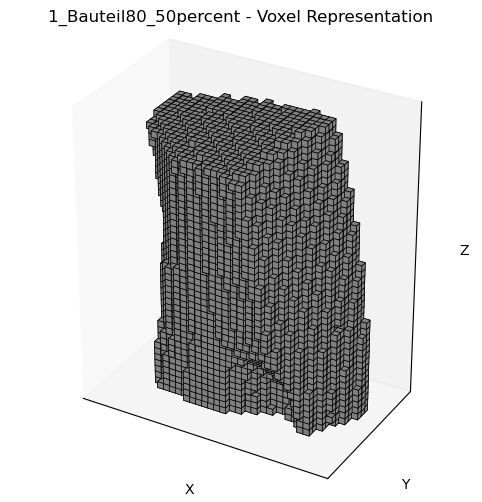

10:35:32 [INFO] Done: '1_Bauteil80_50percent.stl'  ->  output/1_Bauteil80_50percent
10:35:32 [INFO] Slicing '20260424_Wuerfel_97x97x97_n12.stl'  (stl_unit=1000.0, debug=False)


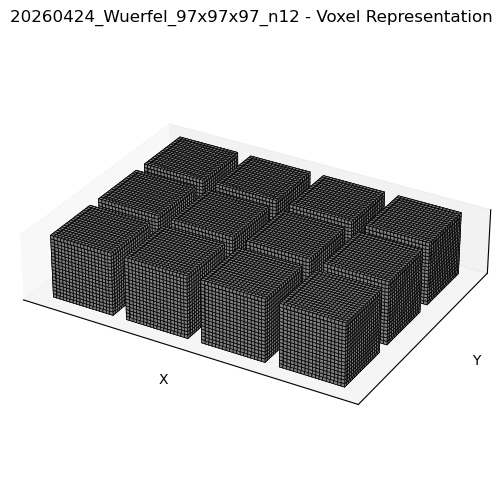

10:36:04 [INFO] Done: '20260424_Wuerfel_97x97x97_n12.stl'  ->  output/20260424_Wuerfel_97x97x97_n12


In [6]:
results  = []
failures = []

for stl_path in stl_files:
    try:
        summary = slice_stl(stl_path, cfg)
        results.append(summary)
    except Exception as exc:
        logger.error("Failed to slice '%s': %s", stl_path.name, exc)
        failures.append((stl_path.name, str(exc)))

## 5 · Summary

In [7]:
if results:
    print("=" * 62)
    print(f"{'STL file':<30} {'Voxels':>8} {'Layers':>7} {'Vol [L]':>9} {'Fits':>5}")
    print("-" * 62)
    for r in results:
        fits_str = "yes" if r["fits"] else "NO !"
        print(f"{r['stl']:<30} {r['voxels']:>8} {r['layers']:>7} "
              f"{r['volume_l']:>9.3f} {fits_str:>5}")
    print("=" * 62)
    print(f"\nOutputs written to: {HERE / 'output'}")

if failures:
    print("\nFailed:")
    for name, err in failures:
        print(f"  {name}: {err}")

STL file                         Voxels  Layers   Vol [L]  Fits
--------------------------------------------------------------
1_Bauteil80_50percent.stl         16953      45     3.140   yes
20260424_Wuerfel_97x97x97_n12.stl    69984      18    12.961   yes

Outputs written to: /home/cwolf/amworkflow/standalone/notebook/output
